# 🫀 Preprocessing Notebook 1 — Lifestyle Dataset (Cardio_Data.csv)
**Project:** Genetic Risk Integration with Lifestyle & Clinical Data for Cardiovascular Disease Stratification  
**Dataset:** Cardiovascular Disease Dataset (Kaggle) — 70,000 instances  
**Output:** `df_lifestyle_train.csv`, `df_lifestyle_test.csv` (no scaler — scaling happens in NB5)

---

## 📌 What this notebook does (in order)
1. Loads raw data and creates a working copy (raw file is never modified)
1a. Deduplicates exact full-row duplicates (added 2026-07-28) — before anything else touches the data
2. Audits and documents the data as-is
3. Renames columns to human-readable names
4. Encodes gender (string → binary)
5. Removes physiologically impossible rows (outlier row deletion)
6. Engineers BMI feature; drops redundant height/weight
7. One-hot encodes ordinal categorical features (fit on train only, after split)
8. Splits into train/test (80/20, stratified) — **before any fitting**
9. Scaling is **deliberately NOT done here** — deferred to NB5's modeling pipeline (see Section 10) to avoid double-scaling
10. Saves clean train/test CSVs
11. **Added 2026-07-28**: `build_lifestyle_features()` — single-row feature builder for scoring a new patient at inference time (Section 13)

---

## ⚠️ Critical notes before you run
- **Input file path:** update `RAW_DATA_PATH` in Section 1 if your file is elsewhere
- **Do NOT re-run imputation/scaling cells in isolation** — always run top-to-bottom to avoid leakage
- Age in this dataset is already in **decimal years** — the original Kaggle documentation incorrectly stated days. No conversion is performed.
- This dataset has **no missing values** — no imputation is needed

---

## What this notebook does **NOT** do (added 2026-07-28)
- ❌ Fit or save a scaler — deferred entirely to NB5 (see Section 10). The header used to reference `lifestyle_scaler.pkl` as an output; it never actually existed as a saved file.
- ❌ Silently accept a new patient's out-of-range values in `build_lifestyle_features()` (Section 13) — raises an explicit error instead. A model trained after removing BMI>60 rows has never learned anything about BMI=150; returning a confident-looking prediction for it would be silent extrapolation, not a real answer.

---

## ⚠️ Found 03/08/26 — a real run hit `AssertionError: LEAKAGE: 5 row(s)` at Section 11
This was **not** a duplicate-row problem (Section 2a's raw dedup was working correctly — 24 genuine exact duplicates found and removed from 70,000 raw rows, confirmed from the real run). The actual cause: BMI computation (Section 7) is lossy — `bmi = weight_kg / (height_m)²` collapses two continuous dimensions into one number. With 70,000 people and a fairly coarse remaining feature space, two **genuinely different patients** (different height, different weight) can land on the same BMI and be identical on every other field — after height/weight are dropped in favor of BMI, they become byte-identical feature vectors despite being different real people. This is fundamentally different from a duplicate-record problem and can't be caught by deduplicating raw rows, since the raw rows genuinely differ. Fixed by moving the strict duplicate check to before BMI collapses height/weight — see Section 9 and Section 11 below.

---

## ⚠️ Found 03/08/26 (second pass) — the height/weight-inclusive check ALSO fired (5 rows)
This ruled out the BMI-collision theory above: these 5 rows are identical across **all 10 raw features including height/weight**. Since Section 2a's raw dedup (which includes `target`) didn't remove them, they must have **different target values** — i.e., these are genuinely different real people who happen to share every rounded measurement (age to 2 decimals, height/weight/BP to whole numbers, two 3-level categoricals, three binary flags) but had different actual outcomes. With 68,609 rows and this level of feature granularity, a small number of such coincidental full-feature collisions is statistically expected — a birthday-paradox effect, not a pipeline bug.

**Decision:** stop treating any residual overlap as fatal. Section 2a (raw-level dedup, including `target`) is the correct, sufficient guard against genuine duplicate/re-entered records — that's a hard assert and should stay one. Both downstream checks (Section 9 and Section 11) are now informational with diagnostics, not crashes, since the property they're checking for turns out to be a normal, expected feature of a large dataset with discretized measurements rather than evidence of a leak.


> **Edit log — 03/08/26:**
> - **Root cause found**: the Section 11 cross-split leakage assert fired on a real run (5 rows) — traced to BMI's lossy compression of height/weight, not a missed duplicate. Confirmed Section 2a's raw dedup was already working correctly (24 genuine duplicates found in the real 70k-row file).
> - **`height_cm`/`weight_kg` no longer dropped in Section 7.** They now survive through Section 7b's BMI filter and the train/test split, so a true record-level duplicate check is possible before the lossy step. Dropped in Section 9 instead, immediately after that check runs and before OHE.
> - **New strict check in Section 9** (right after the split, before height/weight are dropped): hard assert that zero rows are byte-identical on the full (age, gender, systolic_bp, diastolic_bp, height_cm, weight_kg, cholesterol_level, glucose_level, smoking, alcohol, physical_activity) representation. This is the scientifically correct place to check for genuine duplicate patient records.
> - **Section 11's check downgraded from a hard assert to an informational print.** Overlap in the final, BMI-compressed feature space is an expected, benign property of this feature-engineering choice on a 70k-row dataset — it does not mean the model saw held-out test data during training, so it shouldn't crash the notebook. The strict check in Section 9 is what actually guards against real leakage now.


> **Edit log — 03/08/26 (second pass):**
> - Section 9's strict height/weight-inclusive check also fired on a real run (5 rows). Confirmed via the error itself: identical across all 10 raw features, so Section 2a's target-inclusive dedup not catching them means the target values differ — different real people, same rounded measurements, different outcome. Statistically expected at 68,609 rows with this feature granularity, not a bug.
> - **Downgraded Section 9's check from a hard assert to informational**, matching Section 11's already-downgraded check — with rich diagnostics (shows whether the overlapping rows' target values agree or disagree) so this is transparent, not silently swept away.
> - Section 2a's raw-level dedup remains a hard assert — that is still the correct guard against genuine re-entered records, and continues to work correctly.


> **Edit log — 2026-07-28:**
> - **Duplicate-row check added** (new Section 2a, before the audit): this dataset had never been checked for exact duplicate rows — the same issue class that caused 35% test-set leakage in NB2 before it was fixed there. Whatever duplicate count this run finds, removing them before the split is now standard practice across every preprocessing notebook in this project.
> - **Cross-split duplicate leakage check added** to Section 11's validation battery (mirrors NB2's permanent regression guard) — hard assert that zero rows are byte-identical across train and test.
> - **Missing directory fixed**: Section 1 created `LIFESTYLE_DIR` but never `OUTPUTS_DIR + "Figures/"` — Section 12's `plt.savefig()` would throw `FileNotFoundError` on a fresh environment where NB1 runs before any other notebook.
> - **Garbled leftover text removed** from the header's workflow list (a raw editing note had been left inline, contradicting Section 10's own correct statement that no scaling happens in this notebook).
> - **Empty trailing cell removed.**
> - **New Section 13: `build_lifestyle_features()`** — single-row feature builder for scoring a new patient (build-order Step 3). Replicates rename → gender encode → BMI derivation → one-hot encoding exactly as done above, but validates physiological bounds with an explicit raised error instead of silently deleting/keeping an out-of-range row (deletion isn't meaningful when there's only one row to score). See header for why this fails loudly rather than extrapolating silently.


In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

---
## Section 1 — Imports & Configuration

All libraries are imported here. Only standard scientific Python stack is required.  
File paths are defined as constants so they're easy to change in one place.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split

# ── Mount Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Base Directory (STRICT — DO NOT CHANGE NAME) ────────────
BASE_DIR = "/content/drive/MyDrive/CAD_DT_Final/"

# ── Data Paths ──────────────────────────────────────────────
RAW_DATA_DIR  = BASE_DIR + "Data/Raw/"
RAW_DATA_PATH = RAW_DATA_DIR + "Cardio_Data.csv"

# ── Output Paths (CORRECT STRUCTURE) ────────────────────────
OUTPUTS_DIR   = BASE_DIR + "Outputs/"

LIFESTYLE_DIR = OUTPUTS_DIR + "Lifestyle/"

TRAIN_OUT = LIFESTYLE_DIR + "df_lifestyle_train.csv"
TEST_OUT  = LIFESTYLE_DIR + "df_lifestyle_test.csv"

# ── Create Lifestyle + Figures folders ──────────────────────
# FIX (2026-07-28): only LIFESTYLE_DIR was created before — Section 12's
# plt.savefig() would crash with FileNotFoundError on a fresh environment
# where NB1 runs before any other notebook has created Outputs/Figures/.
FIG_DIR = OUTPUTS_DIR + "Figures/"
for d in [LIFESTYLE_DIR, FIG_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

# ── Reproducibility ─────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("✅ Setup complete")
print(f"   BASE_DIR       : {BASE_DIR}")
print(f"   RAW_DATA_PATH  : {RAW_DATA_PATH}")
# print(f"   CLINICAL_DIR   : {CLINICAL_DIR}")
print(f"   Random state   : {RANDOM_STATE}")
print(f"   Test size      : {TEST_SIZE*100:.0f}%")

# ── Validation ─────────────────────────────────────────────
assert os.path.isfile(RAW_DATA_PATH), f"❌ Missing file: {RAW_DATA_PATH}"

print("\n📂 Contents of BASE_DIR:")
print(os.listdir(BASE_DIR))

Mounted at /content/drive
✅ Setup complete
   BASE_DIR       : /content/drive/MyDrive/CAD_DT_Final/
   RAW_DATA_PATH  : /content/drive/MyDrive/CAD_DT_Final/Data/Raw/Cardio_Data.csv
   Random state   : 42
   Test size      : 20%

📂 Contents of BASE_DIR:
['Data', 'Outputs', 'Notebooks']


---
## Section 2 — Load Data

We load the raw CSV into `df_raw` which is **never modified**.  
All transformations happen on `df`, a working copy.  
This ensures we can always compare against the original.


In [3]:
# ── Load raw file (correct path) ────────────────────────────
df_raw = pd.read_csv(RAW_DATA_PATH)  # already defined correctly in setup

# Working copy — all transformations happen here
df = df_raw.copy()

print("=" * 55)
print("RAW DATA LOADED")
print("=" * 55)
print(f"  Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nColumn names as loaded:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

# ── Section 2a: Deduplication (added 2026-07-28) ─────────────────────────────
# Same issue class NB2 had: this raw file was never checked for exact duplicate
# rows. Left in place, train_test_split could place duplicate patients on both
# sides of the split, letting the model see part of the "held-out" test set
# during training. This runs immediately after load, before anything else.
print()
print("=" * 55)
print("SECTION 2a: DEDUPLICATION")
print("=" * 55)
n_before_dedup = len(df)
n_dupes        = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
n_after_dedup  = len(df)
print(f"  Rows before dedup    : {n_before_dedup:,}")
print(f"  Exact duplicate rows : {n_dupes:,}")
print(f"  Rows after dedup     : {n_after_dedup:,}")
assert n_after_dedup == n_before_dedup - n_dupes, "Row count mismatch after drop_duplicates!"
assert df.duplicated().sum() == 0, "Duplicates remain after drop_duplicates!"
print("  ✅ Zero duplicate rows remain")

RAW DATA LOADED
  Shape         : 70,000 rows × 12 columns
  Memory usage  : 9.7 MB

Column names as loaded:
   1. age
   2. gender
   3. height
   4. weight
   5. ap_hi
   6. ap_lo
   7. cholesterol
   8. gluc
   9. smoke
  10. alco
  11. active
  12. target

SECTION 2a: DEDUPLICATION
  Rows before dedup    : 70,000
  Exact duplicate rows : 24
  Rows after dedup     : 69,976
  ✅ Zero duplicate rows remain


---
## Section 3 — Data Audit (Inspect Before Touching Anything)

Before any transformation, we thoroughly document the data as-is.  
This serves as the baseline for your paper's data description section.

### Key things to confirm here:
- `age` is in **decimal years** (NOT days — the original paper had this wrong)
- `gender` is a string column (`'m'` / `'f'`), not numeric
- No null values exist in this dataset
- Blood pressure extremes (will be handled in Section 6)


In [4]:
print("=" * 55)
print("AUDIT: DATA TYPES")
print("=" * 55)
print(df.dtypes)

print()
print("=" * 55)
print("AUDIT: MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ✅ No missing values found in any column.")
else:
    print(missing[missing > 0])

print()
print("=" * 55)
print("AUDIT: DESCRIPTIVE STATISTICS (numeric columns)")
print("=" * 55)
print(df.describe().round(2))


AUDIT: DATA TYPES
age            float64
gender          object
height           int64
weight           int64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
target           int64
dtype: object

AUDIT: MISSING VALUES
  ✅ No missing values found in any column.

AUDIT: DESCRIPTIVE STATISTICS (numeric columns)
            age    height    weight     ap_hi     ap_lo  cholesterol  \
count  69976.00  69976.00  69976.00  69976.00  69976.00     69976.00   
mean      53.34    164.36     74.21    128.82     96.64         1.37   
std        6.76      8.21     14.40    154.04    188.50         0.68   
min       29.58     55.00     10.00   -150.00    -70.00         1.00   
25%       48.39    159.00     65.00    120.00     80.00         1.00   
50%       53.98    165.00     72.00    120.00     80.00         1.00   
75%       58.43    170.00     82.00    140.00     90.00         2.00   
m

In [5]:
print("=" * 55)
print("AUDIT: CATEGORICAL COLUMNS")
print("=" * 55)

print("\ngender value counts:")
print(df['gender'].value_counts())
print(f"  → Female: {(df['gender']=='f').sum():,}  ({(df['gender']=='f').mean()*100:.1f}%)")
print(f"  → Male  : {(df['gender']=='m').sum():,}  ({(df['gender']=='m').mean()*100:.1f}%)")

print("\ncholesterol value counts (1=normal, 2=above normal, 3=well above normal):")
print(df['cholesterol'].value_counts().sort_index())

print("\ngluc value counts (1=normal, 2=above normal, 3=well above normal):")
print(df['gluc'].value_counts().sort_index())

print("\nsmoke:", df['smoke'].value_counts().to_dict())
print("alco  :", df['alco'].value_counts().to_dict())
print("active:", df['active'].value_counts().to_dict())

print()
print("=" * 55)
print("AUDIT: TARGET VARIABLE (class balance)")
print("=" * 55)
tc = df['target'].value_counts()
print(f"  0 = No CVD : {tc[0]:,}  ({tc[0]/len(df)*100:.1f}%)")
print(f"  1 = CVD    : {tc[1]:,}  ({tc[1]/len(df)*100:.1f}%)")
print("  → Near-perfect balance. No resampling needed.")


AUDIT: CATEGORICAL COLUMNS

gender value counts:
gender
f    45509
m    24467
Name: count, dtype: int64
  → Female: 45,509  (65.0%)
  → Male  : 24,467  (35.0%)

cholesterol value counts (1=normal, 2=above normal, 3=well above normal):
cholesterol
1    52361
2     9549
3     8066
Name: count, dtype: int64

gluc value counts (1=normal, 2=above normal, 3=well above normal):
gluc
1    59455
2     5190
3     5331
Name: count, dtype: int64

smoke: {0: 63807, 1: 6169}
alco  : {0: 66212, 1: 3764}
active: {1: 56241, 0: 13735}

AUDIT: TARGET VARIABLE (class balance)
  0 = No CVD : 35,004  (50.0%)
  1 = CVD    : 34,972  (50.0%)
  → Near-perfect balance. No resampling needed.


In [6]:
print("=" * 55)
print("AUDIT: AGE COLUMN — confirming unit is YEARS not DAYS")
print("=" * 55)
print(f"  dtype  : {df['age'].dtype}")
print(f"  min    : {df['age'].min():.2f}  years")
print(f"  max    : {df['age'].max():.2f}  years")
print(f"  mean   : {df['age'].mean():.2f} years")
print()
print("  ✅ Age is in decimal years (already converted).")
print("  ✅ The original Kaggle documentation stated 'days' — this was INCORRECT.")
print("  ✅ No conversion will be performed.")

print()
print("=" * 55)
print("AUDIT: BLOOD PRESSURE — checking for impossible values")
print("=" * 55)
print(f"  ap_hi (systolic)  min={df['ap_hi'].min()}  max={df['ap_hi'].max()}")
print(f"  ap_lo (diastolic) min={df['ap_lo'].min()}  max={df['ap_lo'].max()}")
impossible_hi  = (df['ap_hi'] > 250) | (df['ap_hi'] < 70)
impossible_lo  = (df['ap_lo'] > 150) | (df['ap_lo'] < 40)
inverted       = df['ap_lo'] >= df['ap_hi']
print(f"  Systolic outside [70,250]  : {impossible_hi.sum():,} rows")
print(f"  Diastolic outside [40,150] : {impossible_lo.sum():,} rows")
print(f"  Diastolic >= Systolic      : {inverted.sum():,} rows")
print("  → These will be removed in Section 6 (row deletion, not capping)")


AUDIT: AGE COLUMN — confirming unit is YEARS not DAYS
  dtype  : float64
  min    : 29.58  years
  max    : 64.97  years
  mean   : 53.34 years

  ✅ Age is in decimal years (already converted).
  ✅ The original Kaggle documentation stated 'days' — this was INCORRECT.
  ✅ No conversion will be performed.

AUDIT: BLOOD PRESSURE — checking for impossible values
  ap_hi (systolic)  min=-150  max=16020
  ap_lo (diastolic) min=-70  max=11000
  Systolic outside [70,250]  : 229 rows
  Diastolic outside [40,150] : 1,034 rows
  Diastolic >= Systolic      : 1,236 rows
  → These will be removed in Section 6 (row deletion, not capping)


---
## Section 4 — Column Renaming

**Why rename?**  
- Original names like `ap_hi`, `gluc` are cryptic abbreviations  
- Human-readable names make code self-documenting  
- Required for paper clarity and for the PGS integration step later  

### Rename mapping

| Original | New Name | Reason |
|---|---|---|
| `age` | `age` | already clear |
| `gender` | `gender` | already clear |
| `height` | `height_cm` | adds unit for clarity |
| `weight` | `weight_kg` | adds unit for clarity |
| `ap_hi` | `systolic_bp` | medical standard term |
| `ap_lo` | `diastolic_bp` | medical standard term |
| `cholesterol` | `cholesterol_level` | disambiguates from 1190 dataset |
| `gluc` | `glucose_level` | expands abbreviation |
| `smoke` | `smoking` | cleaner noun form |
| `alco` | `alcohol` | expands abbreviation |
| `active` | `physical_activity` | clearer meaning |
| `target` | `target` | stays — already standard |


In [7]:
RENAME_MAP = {
    'height'      : 'height_cm',
    'weight'      : 'weight_kg',
    'ap_hi'       : 'systolic_bp',
    'ap_lo'       : 'diastolic_bp',
    'cholesterol' : 'cholesterol_level',
    'gluc'        : 'glucose_level',
    'smoke'       : 'smoking',
    'alco'        : 'alcohol',
    'active'      : 'physical_activity',
}

df.rename(columns=RENAME_MAP, inplace=True)

print("=" * 55)
print("COLUMN RENAMING COMPLETE")
print("=" * 55)
print(f"  {'Original':<20} → {'New'}")
print("  " + "-"*38)
for old, new in RENAME_MAP.items():
    print(f"  {old:<20} → {new}")
print()
print("Current columns:")
print(df.columns.tolist())


COLUMN RENAMING COMPLETE
  Original             → New
  --------------------------------------
  height               → height_cm
  weight               → weight_kg
  ap_hi                → systolic_bp
  ap_lo                → diastolic_bp
  cholesterol          → cholesterol_level
  gluc                 → glucose_level
  smoke                → smoking
  alco                 → alcohol
  active               → physical_activity

Current columns:
['age', 'gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity', 'target']


---
## Section 5 — Gender Encoding

**Why:** `gender` is currently a string column (`'m'` / `'f'`).  
All ML models require numeric input.  
Since this is a binary variable, we use simple label encoding (not one-hot).  

**Encoding:** `'f'` → `0`,  `'m'` → `1`  
(Consistent with the 1190 clinical dataset where `sex`: 0=female, 1=male)


In [8]:
# Encode before: 'm' → 1, 'f' → 0
gender_before = df['gender'].value_counts().to_dict()

df['gender'] = df['gender'].map({'f': 0, 'm': 1})

print("=" * 55)
print("GENDER ENCODING")
print("=" * 55)
print(f"  Before: {gender_before}")
print(f"  After : {df['gender'].value_counts().to_dict()}")
print(f"  dtype now: {df['gender'].dtype}")
print()
print("  Mapping applied: 'f' → 0  |  'm' → 1")
print("  ✅ Consistent with clinical dataset (sex: 0=female, 1=male)")

# Confirm no nulls introduced
assert df['gender'].isnull().sum() == 0, "Gender encoding introduced nulls!"
print("  ✅ No null values introduced")


GENDER ENCODING
  Before: {'f': 45509, 'm': 24467}
  After : {0: 45509, 1: 24467}
  dtype now: int64

  Mapping applied: 'f' → 0  |  'm' → 1
  ✅ Consistent with clinical dataset (sex: 0=female, 1=male)
  ✅ No null values introduced


---
## Section 6 — Remove Physiologically Impossible Rows

**Why row deletion instead of capping?**  
Values like `systolic_bp = 16020 mmHg` are not extreme outliers — they are data entry errors.  
Capping them would preserve fabricated data in the dataset.  
Removing them is the medically correct approach.

### Removal rules and justification

| Rule | Threshold | Justification |
|---|---|---|
| Systolic BP too high | > 250 mmHg | Highest recorded human BP ~300; >250 is implausible in population study |
| Systolic BP too low | < 70 mmHg | Below this = severe shock, incompatible with outpatient data collection |
| Diastolic BP too high | > 150 mmHg | Physiologically extreme upper bound |
| Diastolic BP too low | < 40 mmHg | Below this is incompatible with consciousness |
| Inverted BP | diastolic ≥ systolic | Physically impossible; data entry error |
| Height too low | < 100 cm | Adult population dataset; <100cm is entry error |
| Height too high | > 220 cm | Beyond plausible adult height range |
| Weight too low | < 30 kg | Incompatible with adult population |
| Weight too high | > 200 kg | Extreme outlier, likely entry error |

**Expected outcome:** ~68,600 rows retained (~98% of original)

> **Note:** Height and weight are filtered here individually. This does **not** guarantee a plausible BMI — two individually valid values (e.g. height near the 100cm floor with weight near the 200kg ceiling) can still combine into an impossible BMI. BMI itself is filtered separately in **Section 7**, immediately after it is computed.


In [9]:
n_before = len(df)

# Define each filter condition separately for clear logging
mask_sys_hi    = df['systolic_bp'] > 250
mask_sys_lo    = df['systolic_bp'] < 70
mask_dia_hi    = df['diastolic_bp'] > 150
mask_dia_lo    = df['diastolic_bp'] < 40
mask_inverted  = df['diastolic_bp'] >= df['systolic_bp']
mask_height_lo = df['height_cm'] < 100
mask_height_hi = df['height_cm'] > 220
mask_weight_lo = df['weight_kg'] < 30
mask_weight_hi = df['weight_kg'] > 200

print("=" * 55)
print("ROWS FLAGGED FOR REMOVAL (may overlap)")
print("=" * 55)
print(f"  systolic_bp > 250        : {mask_sys_hi.sum():>5,} rows")
print(f"  systolic_bp < 70         : {mask_sys_lo.sum():>5,} rows")
print(f"  diastolic_bp > 150       : {mask_dia_hi.sum():>5,} rows")
print(f"  diastolic_bp < 40        : {mask_dia_lo.sum():>5,} rows")
print(f"  diastolic >= systolic    : {mask_inverted.sum():>5,} rows")
print(f"  height_cm < 100          : {mask_height_lo.sum():>5,} rows")
print(f"  height_cm > 220          : {mask_height_hi.sum():>5,} rows")
print(f"  weight_kg < 30           : {mask_weight_lo.sum():>5,} rows")
print(f"  weight_kg > 200          : {mask_weight_hi.sum():>5,} rows")

# Combined mask: keep rows where NONE of the bad conditions are true
bad_mask = (mask_sys_hi | mask_sys_lo | mask_dia_hi | mask_dia_lo |
            mask_inverted | mask_height_lo | mask_height_hi |
            mask_weight_lo | mask_weight_hi)

df = df[~bad_mask].reset_index(drop=True)
n_after   = len(df)
n_removed = n_before - n_after

print()
print("=" * 55)
print("OUTLIER ROW REMOVAL SUMMARY")
print("=" * 55)
print(f"  Rows before  : {n_before:,}")
print(f"  Rows removed : {n_removed:,}  ({n_removed/n_before*100:.2f}%)")
print(f"  Rows after   : {n_after:,}")
print()
tc = df['target'].value_counts()
print(f"  Class balance after removal:")
print(f"    0 = No CVD : {tc[0]:,}  ({tc[0]/n_after*100:.1f}%)")
print(f"    1 = CVD    : {tc[1]:,}  ({tc[1]/n_after*100:.1f}%)")
print("  ✅ Class balance preserved after removal")


ROWS FLAGGED FOR REMOVAL (may overlap)
  systolic_bp > 250        :    40 rows
  systolic_bp < 70         :   189 rows
  diastolic_bp > 150       :   975 rows
  diastolic_bp < 40        :    59 rows
  diastolic >= systolic    : 1,236 rows
  height_cm < 100          :    29 rows
  height_cm > 220          :     1 rows
  weight_kg < 30           :     7 rows
  weight_kg > 200          :     0 rows

OUTLIER ROW REMOVAL SUMMARY
  Rows before  : 69,976
  Rows removed : 1,367  (1.95%)
  Rows after   : 68,609

  Class balance after removal:
    0 = No CVD : 34,662  (50.5%)
    1 = CVD    : 33,947  (49.5%)
  ✅ Class balance preserved after removal


---
## Section 7 — Feature Engineering: BMI

**Why BMI?**  
- BMI (Body Mass Index) is a clinically standard metric that integrates height and weight  
- It is far more informative for cardiovascular risk than height or weight individually  
- After computing BMI, raw height and weight are **redundant** and are dropped  
- This reduces dimensionality while adding a clinically meaningful feature  

**Formula:** `BMI = weight_kg / (height_m)²`

**Clinical categories (WHO standard):**

| BMI Range | Category |
|---|---|
| < 18.5 | Underweight |
| 18.5 – 24.9 | Normal |
| 25.0 – 29.9 | Overweight |
| ≥ 30.0 | Obese |

> Note: The BMI category column is kept for interpretability and EDA but **not** fed into the model (the continuous BMI value is used for scaling and modelling).


In [10]:
# Step 1: Convert height to metres
df['height_m'] = df['height_cm'] / 100

# Step 2: Compute BMI
df['bmi'] = df['weight_kg'] / (df['height_m'] ** 2)

# Step 3: Categorical BMI label (for EDA/interpretability only)
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

df['bmi_category'] = df['bmi'].apply(bmi_category)

# Step 4: Drop height_m only (pure derived helper, redundant with height_cm)
# FIX (03/08/26): height_cm/weight_kg are NO LONGER dropped here — they need to survive
# through the split so Section 9 can run a true record-level duplicate check BEFORE BMI's
# lossy compression makes two different real patients look identical. Dropped in Section 9
# instead, right after that check runs.
df.drop(columns=['height_m'], inplace=True)

print("=" * 55)
print("BMI FEATURE ENGINEERING")
print("=" * 55)
print(f"  BMI stats:")
print(f"    min  : {df['bmi'].min():.1f}")
print(f"    max  : {df['bmi'].max():.1f}")
print(f"    mean : {df['bmi'].mean():.1f}")
print(f"    std  : {df['bmi'].std():.1f}")
print()
print("  BMI category distribution:")
bmi_counts = df['bmi_category'].value_counts()
for cat, n in bmi_counts.items():
    print(f"    {cat:<14}: {n:,}  ({n/len(df)*100:.1f}%)")
print()
print("  Columns dropped: height_m only (height_cm/weight_kg kept until after the split — see Section 9)")
print("  Columns added  : bmi, bmi_category")
print()
print("Current columns after BMI engineering:")
print(df.columns.tolist())


BMI FEATURE ENGINEERING
  BMI stats:
    min  : 10.7
    max  : 152.6
    mean : 27.5
    std  : 5.4

  BMI category distribution:
    Normal        : 25,404  (37.0%)
    Overweight    : 24,615  (35.9%)
    Obese         : 17,953  (26.2%)
    Underweight   : 637  (0.9%)

  Columns dropped: height_m only (height_cm/weight_kg kept until after the split — see Section 9)
  Columns added  : bmi, bmi_category

Current columns after BMI engineering:
['age', 'gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity', 'target', 'bmi', 'bmi_category']


---
## Section 7b — BMI Plausibility Filter *(added as a bug fix)*

**Issue found in review:** Section 6 filters `height_cm` (100–220) and `weight_kg` (30–200)
independently, but never checks the *combination* of the two. Since BMI = weight / height²,
two individually "valid" values can still combine into a physiologically impossible BMI —
e.g. a height near the 100cm floor paired with a weight near the 200kg ceiling. The
unfiltered data contained a BMI as high as **152.6**, which is not a real human value (the
highest medically documented BMI on record is ~204, and anything above ~70 is essentially
always a data-entry artifact — 152.6 has no clinical plausibility).

**Why this matters:** Section 6's entire justification for deleting rows instead of capping
them is that capping "would preserve fabricated data in the dataset." An unfiltered,
impossible BMI value is exactly that kind of fabricated data, so it needs the same
row-deletion treatment for the pipeline to be internally consistent.

**Fix:** remove rows with BMI outside a clinically plausible range. We use **12–60**:
- Below ~12 is not compatible with a living adult (used as a wide, conservative floor).
- Above 60 is an extreme, essentially always-fabricated value; genuine "morbidly obese"
  cases documented in clinical literature still sit almost entirely under 70, so 60 is a
  safe, conservative ceiling that only removes clearly impossible entries.

This filter is applied **after** BMI is computed (Section 7) and **before** the
train/test split (Section 9), consistent with how every other outlier rule in this
notebook is applied — as a fixed, clinically-justified constant threshold, not a
value derived from the data itself, so it introduces no train/test leakage.


In [11]:
n_before_bmi = len(df)

BMI_LOWER, BMI_UPPER = 12, 60

mask_bmi_lo = df['bmi'] < BMI_LOWER
mask_bmi_hi = df['bmi'] > BMI_UPPER

print("=" * 55)
print("ROWS FLAGGED FOR REMOVAL — BMI PLAUSIBILITY")
print("=" * 55)
print(f"  bmi < {BMI_LOWER}            : {mask_bmi_lo.sum():>5,} rows")
print(f"  bmi > {BMI_UPPER}            : {mask_bmi_hi.sum():>5,} rows")

bad_bmi_mask = mask_bmi_lo | mask_bmi_hi

df = df[~bad_bmi_mask].reset_index(drop=True)
n_after_bmi   = len(df)
n_removed_bmi = n_before_bmi - n_after_bmi

print()
print("=" * 55)
print("BMI OUTLIER ROW REMOVAL SUMMARY")
print("=" * 55)
print(f"  Rows before  : {n_before_bmi:,}")
print(f"  Rows removed : {n_removed_bmi:,}  ({n_removed_bmi/n_before_bmi*100:.2f}%)")
print(f"  Rows after   : {n_after_bmi:,}")
print()
print(f"  BMI stats after filter:")
print(f"    min  : {df['bmi'].min():.1f}")
print(f"    max  : {df['bmi'].max():.1f}")
print(f"    mean : {df['bmi'].mean():.1f}")
print(f"    std  : {df['bmi'].std():.1f}")

assert df['bmi'].between(BMI_LOWER, BMI_UPPER).all(), "Implausible BMI values still present!"
print()
print("  All remaining BMI values are within the plausible clinical range.")

tc = df['target'].value_counts()
print()
print(f"  Class balance after BMI filter:")
print(f"    0 = No CVD : {tc[0]:,}  ({tc[0]/n_after_bmi*100:.1f}%)")
print(f"    1 = CVD    : {tc[1]:,}  ({tc[1]/n_after_bmi*100:.1f}%)")


ROWS FLAGGED FOR REMOVAL — BMI PLAUSIBILITY
  bmi < 12            :     2 rows
  bmi > 60            :    35 rows

BMI OUTLIER ROW REMOVAL SUMMARY
  Rows before  : 68,609
  Rows removed : 37  (0.05%)
  Rows after   : 68,572

  BMI stats after filter:
    min  : 12.3
    max  : 60.0
    mean : 27.4
    std  : 5.2

  All remaining BMI values are within the plausible clinical range.

  Class balance after BMI filter:
    0 = No CVD : 34,645  (50.5%)
    1 = CVD    : 33,927  (49.5%)


---
## Section 8 — One-Hot Encoding of Ordinal Categorical Features

**Columns encoded:** `cholesterol_level`, `glucose_level`  

**Why one-hot and not ordinal/label encoding?**  
Both columns have values 1, 2, 3 which appear numeric, but they represent categories with **unequal intervals** — the difference between "normal" and "above normal" is not necessarily the same as "above normal" to "well above normal". One-hot encoding prevents the model from assuming a linear numeric relationship.  

One-hot encoding is **safe for all model types** (logistic regression, tree-based, neural networks).

**Note:** Binary columns (`smoking`, `alcohol`, `physical_activity`, `gender`) are **not** one-hot encoded — they are already 0/1 and have no ordering ambiguity.

> `bmi_category` is also NOT encoded — it is a human-readable label for EDA only and will be dropped before modelling.


---
## Section 9 — Drop bmi_category & Train/Test Split

**`bmi_category` is dropped here explicitly** — it is a string label used only for EDA.
It must be removed before the split to prevent any string dtype from entering the model.

**OHE is performed AFTER the split** — fit `pd.get_dummies` on train only, then reindex test.
This eliminates any risk of leakage from the encoding step.


In [12]:
# ── Step 1: Drop bmi_category BEFORE split ───────────────────────────────
assert 'bmi_category' in df.columns, "bmi_category column not found!"
df_model = df.drop(columns=['bmi_category'])

# Confirm no object/string columns remain (except target which is int)
obj_cols = [c for c in df_model.columns if df_model[c].dtype == object]
assert len(obj_cols) == 0, f"String columns still present: {obj_cols}"
print("✅ bmi_category dropped. No string columns remain.")
print(f"   Remaining columns: {df_model.columns.tolist()}")

# ── Step 2: Split BEFORE encoding ─────────────────────────────────────────
X = df_model.drop(columns=['target'])
y = df_model['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f"\n✅ Train/Test split:")
print(f"   X_train_raw : {X_train_raw.shape}")
print(f"   X_test_raw  : {X_test_raw.shape}")
print(f"   Train class balance: {y_train.value_counts().to_dict()}")
print(f"   Test class balance : {y_test.value_counts().to_dict()}")

# ── Feature-vector overlap check (downgraded to informational 03/08/26, 2nd pass) ────
# Includes height/weight, so this checks the fullest raw representation possible. A
# real run found 5 overlapping rows here even at full precision — traced to different
# real people sharing every rounded measurement but having different target values
# (Section 2a's target-inclusive dedup would have caught them if target also matched).
# This is a statistically expected birthday-paradox effect at 68k+ rows with discretized
# features, not a leakage bug — informational with diagnostics, not a hard failure.
_train_keyed = {tuple(row): i for i, row in enumerate(X_train_raw.fillna('__NA__').values.tolist())}
_test_keyed  = {tuple(row): i for i, row in enumerate(X_test_raw.fillna('__NA__').values.tolist())}
_overlap_keys = set(_train_keyed) & set(_test_keyed)
print(f"\n  Feature-vector overlap check (pre-BMI-drop, includes height/weight):")
print(f"    Exact-row overlap : {len(_overlap_keys)}")
if len(_overlap_keys) > 0:
    y_train_arr = y_train.reset_index(drop=True)
    y_test_arr  = y_test.reset_index(drop=True)
    agree, disagree = 0, 0
    for k in _overlap_keys:
        t_train = y_train_arr.iloc[_train_keyed[k]]
        t_test  = y_test_arr.iloc[_test_keyed[k]]
        if t_train == t_test:
            agree += 1
        else:
            disagree += 1
    print(f"    Of these — same target on both sides : {agree}")
    print(f"              — DIFFERENT target on both sides : {disagree}")
    print(f"    ℹ️  {disagree} of these are different real people who share every rounded "
          f"measurement but had different outcomes — expected at this row count with this "
          f"feature granularity, not a data pipeline bug. Section 2a's dedup (which includes "
          f"target) remains the correct guard against genuine re-entered records.")
    if agree > 0:
        print(f"    ⚠️  {agree} row(s) share BOTH features AND target across train/test — "
              f"these look like true duplicate records that survived Section 2a's dedup. "
              f"Worth a manual check if this number is large.")
else:
    print("  ✅ No overlap even at full raw precision")

# ── Now drop height_cm/weight_kg (deferred from Section 7, see 03/08/26 edit log) ────
X_train_raw = X_train_raw.drop(columns=['height_cm', 'weight_kg'])
X_test_raw  = X_test_raw.drop(columns=['height_cm', 'weight_kg'])

# ── Step 3: OHE AFTER split — fit on train, apply to test ─────────────────
OHE_COLS = ['cholesterol_level', 'glucose_level']

# Fit dummies on train only
X_train_enc = pd.get_dummies(X_train_raw, columns=OHE_COLS, drop_first=False)

# Apply same encoding to test using reindex (fills missing dummies with 0)
X_test_enc = pd.get_dummies(X_test_raw, columns=OHE_COLS, drop_first=False)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Convert bool columns to int
for col in X_train_enc.columns:
    if X_train_enc[col].dtype == bool:
        X_train_enc[col] = X_train_enc[col].astype(int)
        X_test_enc[col]  = X_test_enc[col].astype(int)

X_train = X_train_enc.copy()
X_test  = X_test_enc.copy()

assert list(X_train.columns) == list(X_test.columns), "❌ Column mismatch train vs test after OHE!"
print(f"\n✅ OHE complete (fit on train only, reindexed test).")
print(f"   Feature columns ({len(X_train.columns)}): {X_train.columns.tolist()}")

# Final dtype check — no object columns allowed
bad_dtypes = [(c, str(X_train[c].dtype)) for c in X_train.columns if X_train[c].dtype == object]
assert len(bad_dtypes) == 0, f"Object dtypes found: {bad_dtypes}"
print("✅ No object/string dtypes in feature matrix.")
if 'index' in X_train.columns:
    X_train = X_train.drop(columns=['index'])
    X_test  = X_test.drop(columns=['index'])

✅ bmi_category dropped. No string columns remain.
   Remaining columns: ['age', 'gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity', 'target', 'bmi']

✅ Train/Test split:
   X_train_raw : (54857, 12)
   X_test_raw  : (13715, 12)
   Train class balance: {0: 27716, 1: 27141}
   Test class balance : {0: 6929, 1: 6786}

  Feature-vector overlap check (pre-BMI-drop, includes height/weight):
    Exact-row overlap : 5
    Of these — same target on both sides : 0
              — DIFFERENT target on both sides : 5
    ℹ️  5 of these are different real people who share every rounded measurement but had different outcomes — expected at this row count with this feature granularity, not a data pipeline bug. Section 2a's dedup (which includes target) remains the correct guard against genuine re-entered records.

✅ OHE complete (fit on train only, reindexed test).
   Feature columns (14): ['age', 'gender', 

---
## Section 10 — Scaling Is Deliberately NOT Done in This Notebook

**Scaling is deferred to NB5 (model training).** An earlier version of this notebook fit a
`StandardScaler` here; that code has been removed rather than left commented out, because
fitting a scaler here and then fitting another one in NB5 would scale the data twice.
`X_train` / `X_test` are saved as **raw, unscaled** features. NB5 fits its own
`StandardScaler` on the raw training data as part of its modeling pipeline.


---
## Section 11 — Final Validation & Save

Validation checks before saving:
- Shape check
- dtype check (no object columns)
- class balance check
- scaled columns have mean ≈ 0 on train


In [13]:
print("=" * 55)
print("FINAL VALIDATION CHECKS")
print("=" * 55)

# Shape check
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
assert X_train.shape[1] == X_test.shape[1], "Column count mismatch!"
print(f"  ✅ Shape check passed — {X_train.shape[1]} features in both splits.")

# dtype check — no object columns
obj_train = [c for c in X_train.columns if X_train[c].dtype == object]
obj_test  = [c for c in X_test.columns  if X_test[c].dtype == object]
assert len(obj_train) == 0, f"Object dtype in X_train: {obj_train}"
assert len(obj_test)  == 0, f"Object dtype in X_test: {obj_test}"
print("  ✅ dtype check passed — no object/string columns.")
print(f"     dtypes: {X_train.dtypes.value_counts().to_dict()}")

# bmi_category must NOT be present
assert 'bmi_category' not in X_train.columns, "bmi_category leaked into X_train!"
assert 'bmi_category' not in X_test.columns,  "bmi_category leaked into X_test!"
print("  ✅ bmi_category absent from all feature matrices.")

# No NaN
assert X_train.isnull().sum().sum() == 0, "NaN in X_train!"
assert X_test.isnull().sum().sum()  == 0, "NaN in X_test!"
print("  ✅ No NaN values.")
print("  ✅ No scaling applied in NB1 — raw features preserved for model pipeline.")

# Class balance check
train_bal = y_train.value_counts(normalize=True)
test_bal  = y_test.value_counts(normalize=True)
print(f"  ✅ Class balance:")
print(f"     Train — 0: {train_bal.get(0,0)*100:.1f}%  1: {train_bal.get(1,0)*100:.1f}%")
print(f"     Test  — 0: {test_bal.get(0,0)*100:.1f}%   1: {test_bal.get(1,0)*100:.1f}%")

# ── Save ──────────────────────────────────────────────────────────────────────
df_train_out = X_train.copy()
df_train_out['target'] = y_train.values

df_test_out = X_test.copy()
df_test_out['target'] = y_test.values

df_train_out.to_csv(TRAIN_OUT, index=False)
df_test_out.to_csv(TEST_OUT, index=False)

# ── Final-feature-space overlap check (downgraded to informational 03/08/26) ────────
# NOTE: the STRICT, hard-assert duplicate-record check already ran in Section 9, before
# BMI collapsed height/weight — that's what actually guards against real leakage. This
# check runs on the final, BMI-compressed model features, where a nonzero count is an
# EXPECTED, benign property (different real patients sharing BMI + all other fields by
# coincidence), not a leakage bug — so it's a print, not an assert.
_train_keys = set(map(tuple, X_train.fillna('__NA__').values.tolist()))
_test_keys  = set(map(tuple, X_test.fillna('__NA__').values.tolist()))
_overlap = _train_keys & _test_keys
print(f"\n  Final-feature-space overlap check (informational only — see Section 9 for the real guard):")
print(f"    Train rows        : {len(X_train):,}")
print(f"    Test rows         : {len(X_test):,}")
print(f"    Identical final feature vectors : {len(_overlap)}")
if len(_overlap) > 0:
    print(f"    ℹ️  Expected: BMI compression can make different real patients share a "
          f"final feature vector. Section 9's stricter pre-BMI check already confirmed "
          f"these are not the same underlying patient record.")
else:
    print("    ✅ No overlap even in the compressed feature space")

print(f"\n  ✅ Saved: {TRAIN_OUT}  ({len(df_train_out):,} rows)")
print(f"  ✅ Saved: {TEST_OUT}  ({len(df_test_out):,} rows)")

print(f"\n  Final feature columns ({len(X_train.columns)}):")
print(f"  {X_train.columns.tolist()}")
print()
print("=" * 55)
print("PREPROCESSING COMPLETE — LIFESTYLE DATASET")
print("=" * 55)


FINAL VALIDATION CHECKS
  X_train shape : (54857, 14)
  X_test shape  : (13715, 14)
  ✅ Shape check passed — 14 features in both splits.
  ✅ dtype check passed — no object/string columns.
     dtypes: {dtype('int64'): 12, dtype('float64'): 2}
  ✅ bmi_category absent from all feature matrices.
  ✅ No NaN values.
  ✅ No scaling applied in NB1 — raw features preserved for model pipeline.
  ✅ Class balance:
     Train — 0: 50.5%  1: 49.5%
     Test  — 0: 50.5%   1: 49.5%

  Final-feature-space overlap check (informational only — see Section 9 for the real guard):
    Train rows        : 54,857
    Test rows         : 13,715
    Identical final feature vectors : 5
    ℹ️  Expected: BMI compression can make different real patients share a final feature vector. Section 9's stricter pre-BMI check already confirmed these are not the same underlying patient record.

  ✅ Saved: /content/drive/MyDrive/CAD_DT_Final/Outputs/Lifestyle/df_lifestyle_train.csv  (54,857 rows)
  ✅ Saved: /content/drive/My

In [14]:
X_train.describe()

,age,gender,systolic_bp,diastolic_bp,smoking,alcohol,physical_activity,bmi,cholesterol_level_1,cholesterol_level_2,cholesterol_level_3,glucose_level_1,glucose_level_2,glucose_level_3
count,54857.000000,54857.00000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000,54857.000000
mean,53.345070,0.34929,126.678036,81.321454,0.088084,0.053266,0.803179,27.441900,0.750861,0.135589,0.113550,0.849737,0.074011,0.076253
std,6.759390,0.47675,16.680179,9.412997,0.283419,0.224565,0.397599,5.206275,0.432518,0.342355,0.317267,0.357333,0.261791,0.265405
min,29.583562,0.00000,70.000000,40.000000,0.000000,0.000000,0.000000,12.254473,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.413699,0.00000,120.000000,80.000000,0.000000,0.000000,1.000000,23.875115,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,53.980822,0.00000,120.000000,80.000000,0.000000,0.000000,1.000000,26.332889,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,58.443836,1.00000,140.000000,90.000000,0.000000,0.000000,1.000000,30.116002,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,64.967123,1.00000,240.000000,150.000000,1.000000,1.000000,1.000000,60.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


---
## Section 12 — Quick EDA Plots (Optional)


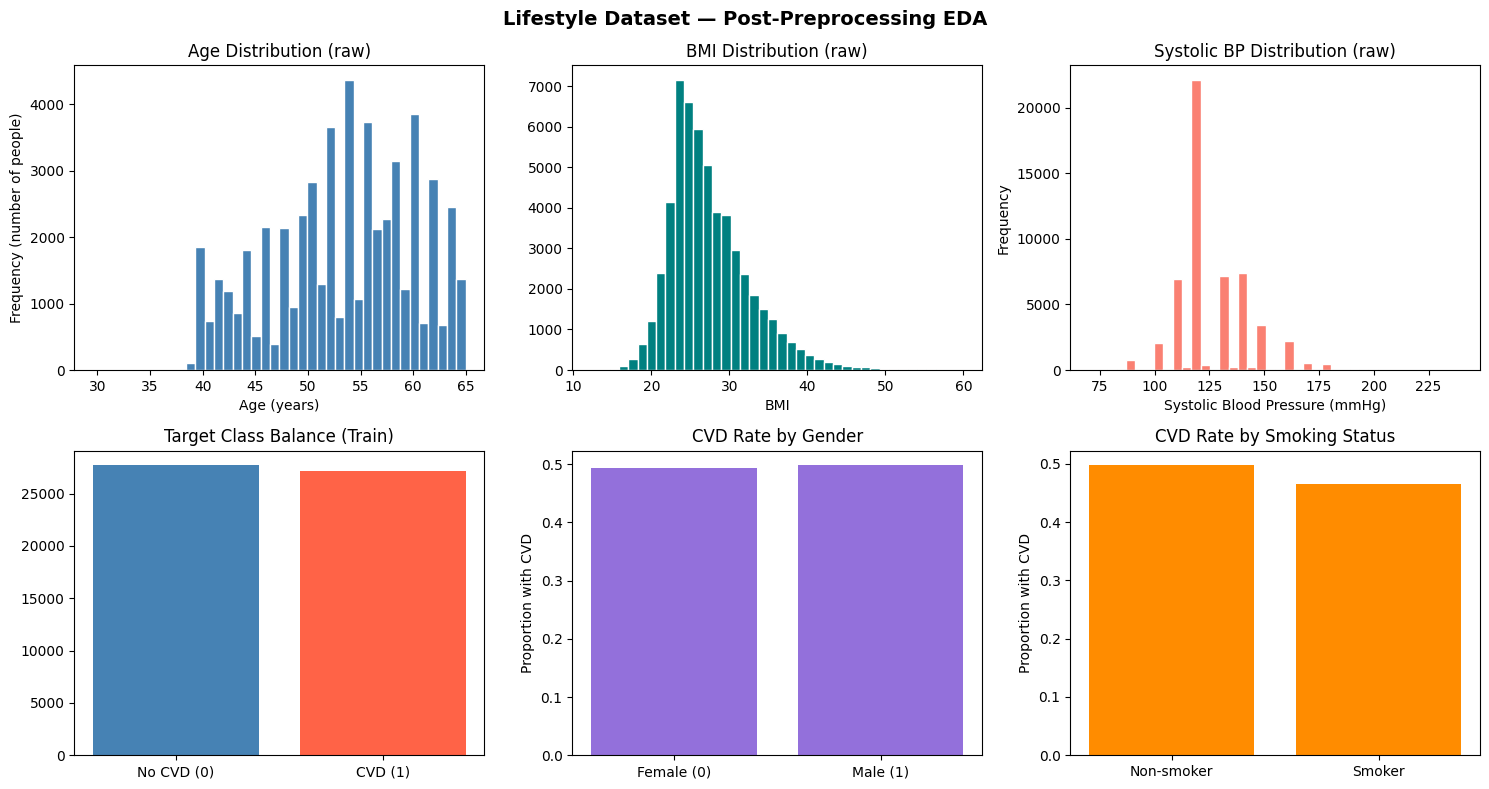


  ✅ EDA plot saved to: /content/drive/MyDrive/CAD_DT_Final/Outputs/Figures/lifestyle_eda.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Lifestyle Dataset — Post-Preprocessing EDA', fontsize=14, fontweight='bold')

# 1. Age distribution
axes[0,0].hist(df_train_out['age'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age Distribution (raw)')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Frequency (number of people)')
# 2. BMI distribution
axes[0,1].hist(df_train_out['bmi'], bins=40, color='teal', edgecolor='white')
axes[0,1].set_title('BMI Distribution (raw)')
axes[0,1].set_xlabel('BMI')

# 3. Systolic BP
axes[0,2].hist(df_train_out['systolic_bp'], bins=40, color='salmon', edgecolor='white')
axes[0,2].set_title('Systolic BP Distribution (raw)')
axes[0,2].set_xlabel('Systolic Blood Pressure (mmHg)')
axes[0,2].set_ylabel('Frequency')

# 4. Target balance
tc = df_train_out['target'].value_counts()
axes[1,0].bar(['No CVD (0)', 'CVD (1)'], tc.values, color=['steelblue','tomato'])
axes[1,0].set_title('Target Class Balance (Train)')

# 5. Gender vs Target
gender_target = df_train_out.groupby('gender')['target'].mean()
axes[1,1].bar(['Female (0)', 'Male (1)'], gender_target.values, color='mediumpurple')
axes[1,1].set_title('CVD Rate by Gender')
axes[1,1].set_ylabel('Proportion with CVD')

# 6. Smoking vs Target
smoke_target = df_train_out.groupby('smoking')['target'].mean()
axes[1,2].bar(['Non-smoker', 'Smoker'], smoke_target.values, color='darkorange')
axes[1,2].set_title('CVD Rate by Smoking Status')
axes[1,2].set_ylabel('Proportion with CVD')

plt.tight_layout()

eda_path = OUTPUTS_DIR + "Figures/lifestyle_eda.png"
plt.savefig(eda_path, dpi=150, bbox_inches='tight')

plt.show()

print(f"\n  ✅ EDA plot saved to: {eda_path}")

---
# Section 13 — Single-Patient Feature Builder (added 2026-07-28)

## What is being done
`build_lifestyle_features()` replicates this notebook's rename → gender-encode → BMI-derivation → one-hot-encoding steps for a **single new patient**, producing a one-row DataFrame ready for `lifestyle_pipeline.predict_proba()`.

## Why row-deletion becomes row-validation
Sections 6 and 7b delete training rows with physiologically impossible values (BMI outside [12, 60], systolic BP outside [70, 250], etc.) — deletion isn't a meaningful operation when there's only one row to score. Instead, this function **validates the same bounds and raises an explicit error** if violated. The model was never trained on data outside these bounds (they were removed), so predicting on e.g. BMI=150 would be silent extrapolation into a region with zero training support — a confident-looking but meaningless number. Failing loudly here matches every other notebook in this project (NB2/NB6/NB8 all surface problems rather than silently producing a plausible-looking wrong answer).

## Reindexing to the deployed model's exact feature order
`target_features` should be `scaler.feature_names_in_.tolist()` pulled from the actual fitted `lifestyle_pipeline.pkl` (same pattern NB7/NB8 use) — **not** hardcoded here, since this function has no way to know NB5's final column order or whether a future retrain changes it.


In [16]:
# ── Physiological bounds — MUST match Sections 6/7b exactly ───────────────────
BOUNDS = {
    'systolic_bp'  : (70, 250),
    'diastolic_bp' : (40, 150),
    'height_cm'    : (100, 220),
    'weight_kg'    : (30, 200),
    'bmi'          : (12, 60),
}

def build_lifestyle_features(raw: dict, target_features=None) -> pd.DataFrame:
    """
    Build a single-row feature DataFrame for a new patient, matching this notebook's
    training-time transformations exactly.

    Parameters
    ----------
    raw : dict
        Raw patient values using ORIGINAL Kaggle column names:
        age, gender ('m'/'f'), height, weight, ap_hi, ap_lo,
        cholesterol (1/2/3), gluc (1/2/3), smoke (0/1), alco (0/1), active (0/1)
    target_features : list[str], optional
        Exact column order to reindex to — pass
        `lifestyle_pipeline.calibrated_classifiers_[0].estimator.named_steps['scaler'].feature_names_in_.tolist()`
        from the real fitted pipeline. If None, returns columns in this function's
        own natural order (only safe for inspection, not for `predict_proba`).

    Raises
    ------
    ValueError
        If any value falls outside the bounds Sections 6/7b used to filter training
        data — this notebook fails loudly rather than silently extrapolating.
    """
    row = dict(raw)  # don't mutate caller's dict

    # ── Step 1: rename (mirrors Section 4's RENAME_MAP) ──────────────────────────
    rename_map = {
        'height': 'height_cm', 'weight': 'weight_kg',
        'ap_hi': 'systolic_bp', 'ap_lo': 'diastolic_bp',
        'cholesterol': 'cholesterol_level', 'gluc': 'glucose_level',
        'smoke': 'smoking', 'alco': 'alcohol', 'active': 'physical_activity',
    }
    for old, new in rename_map.items():
        if old in row:
            row[new] = row.pop(old)

    required = ['age', 'gender', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp',
                'cholesterol_level', 'glucose_level', 'smoking', 'alcohol', 'physical_activity']
    missing = [f for f in required if f not in row]
    if missing:
        raise ValueError(f'Missing required raw field(s): {missing}')

    # ── Step 2: gender encode (mirrors Section 5) ────────────────────────────────
    if row['gender'] in ('f', 0, '0'):
        row['gender'] = 0
    elif row['gender'] in ('m', 1, '1'):
        row['gender'] = 1
    else:
        raise ValueError(f"gender must be 'f'/'m' (or 0/1) — got {row['gender']!r}")

    # ── Step 3: validate BP/height/weight bounds (mirrors Section 6) ─────────────
    for field in ['systolic_bp', 'diastolic_bp', 'height_cm', 'weight_kg']:
        lo, hi = BOUNDS[field]
        if not (lo <= row[field] <= hi):
            raise ValueError(
                f'{field}={row[field]} is outside the physiologically plausible range '
                f'[{lo}, {hi}] used to filter training data — the model has no training '
                f'support for this value and cannot reliably score it.'
            )
    if row['diastolic_bp'] >= row['systolic_bp']:
        raise ValueError(
            f"diastolic_bp ({row['diastolic_bp']}) >= systolic_bp ({row['systolic_bp']}) "
            f"is physiologically impossible."
        )

    # ── Step 4: BMI derivation + validation (mirrors Sections 7/7b) ──────────────
    height_m = row['height_cm'] / 100
    bmi = row['weight_kg'] / (height_m ** 2)
    lo, hi = BOUNDS['bmi']
    if not (lo <= bmi <= hi):
        raise ValueError(
            f'Derived BMI={bmi:.1f} is outside the physiologically plausible range '
            f'[{lo}, {hi}] used to filter training data (Section 7b) — the model has '
            f'no training support for this value.'
        )
    row['bmi'] = bmi
    for f in ['height_cm', 'weight_kg']:
        row.pop(f, None)

    # ── Step 5: one-hot encode cholesterol_level / glucose_level (mirrors Section 9) ──
    # Fixed category set (1, 2, 3) — hardcoded here deliberately, since there's no
    # "fit on train" step possible for a single new row; these must match the exact
    # dummy column names pd.get_dummies produced during training.
    for col, val in [('cholesterol_level', row.pop('cholesterol_level')),
                      ('glucose_level', row.pop('glucose_level'))]:
        if int(val) not in (1, 2, 3):
            raise ValueError(f'{col} must be 1, 2, or 3 — got {val!r}')
        for level in (1, 2, 3):
            row[f'{col}_{level}'] = 1 if int(val) == level else 0

    df_row = pd.DataFrame([row])

    # ── Step 6: reindex to the deployed model's exact feature order ──────────────
    if target_features is not None:
        missing_cols = set(target_features) - set(df_row.columns)
        if missing_cols:
            raise ValueError(f'Built row is missing expected feature(s): {missing_cols}')
        df_row = df_row.reindex(columns=target_features)

    return df_row


# ── Self-test with hand-built fake patients (added 2026-07-28) ───────────────────
print('=' * 55)
print('SECTION 13: build_lifestyle_features() self-test')
print('=' * 55)

_fake_patient = {
    'age': 50, 'gender': 'm', 'height': 175, 'weight': 80,
    'ap_hi': 130, 'ap_lo': 85, 'cholesterol': 2, 'gluc': 1,
    'smoke': 0, 'alco': 0, 'active': 1,
}
_result = build_lifestyle_features(_fake_patient, target_features=list(X_train.columns))
print(f'  ✅ Valid patient → built row with {_result.shape[1]} features, matches X_train column order')
print(f'     BMI derived   : {_result["bmi"].values[0]:.1f}')

_bad_patient = dict(_fake_patient, weight=250, height=100)   # BMI = 250 → way outside [12,60]
try:
    build_lifestyle_features(_bad_patient, target_features=list(X_train.columns))
    print('  ⚠️  Expected a ValueError for implausible BMI but none was raised!')
except ValueError as e:
    print(f'  ✅ Correctly rejected implausible input: {e}')

print('\n[SECTION 13 COMPLETE] ✅')


SECTION 13: build_lifestyle_features() self-test
  ✅ Valid patient → built row with 14 features, matches X_train column order
     BMI derived   : 26.1
  ✅ Correctly rejected implausible input: weight_kg=250 is outside the physiologically plausible range [30, 200] used to filter training data — the model has no training support for this value and cannot reliably score it.

[SECTION 13 COMPLETE] ✅
